
<div style="border:solid green 2px; padding: 20px">

👋 **¡Hola! Soy Dot, tu revisor de IA.**

He completado la primera revisión de tu código. A continuación, encontrarás mis comentarios y sugerencias de mejora.

**¿Qué debes hacer ahora?**

1. **Revisar:** Lee mis comentarios en el notebook más abajo.
2. **Decidir:**
* **¿Estás de acuerdo con el feedback?** ¡Genial! Actualiza tu código según las sugerencias.
* **¿No estás de acuerdo o crees que es un error?** ¡No hay problema! Puedes dejar tu código exactamente como está.


3. **Volver a enviar:** Envía tu proyecto de nuevo. **Tu próxima iteración será revisada por un experto humano**, independientemente de si hiciste cambios o no.

-------------------------------------------------------------------------------------------------------------
Mis comentarios están más abajo. **Te pido amablemente que no los muevas, modifiques ni elimines**.

Verás mis comentarios resaltados en cuadros verdes, amarillos o rojos como estos:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Correcto. Todo se ha hecho exitosamente.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones.
</div>



<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>

¡Hola! Catalina ¿como vas? 

Soy Santiago Sierra y estoy encargado de En esta segunda revisión verifiqué los 11 puntos en rojo ❌ y los 9 en amarillo 🟡 de la iteración 1. La gran mayoría quedó resuelta — buen trabajo. Sin embargo, al revisar con cuidado encontré un problema nuevo y crítico: el notebook <b>no se ejecuta de forma limpia de principio a fin</b>. Dos celdas dependen de columnas que todavía no existen en ese punto del código (solo "funcionan" porque se ejecutaron fuera de orden en tu sesión de Jupyter). Te dejo el detalle exacto más abajo, en las celdas correspondientes.
</div>

<div class="alert alert-block alert-success">
<b>Review General. (Iteración 3)</b>

¡Hola Catalina! Aquí va la tercera revisión. Antes que nada, excelente noticia: verifiqué cuidadosamente el problema crítico de reproducibilidad que señaló Santiago en la Iteración 2 (las celdas que dependían de columnas que aún no existían en una ejecución limpia) y puedo confirmar que el notebook **ahora se ejecuta de principio a fin sin errores** — los números de ejecución de las celdas son consecutivos del 1 al 48, lo cual confirma un "Restart & Run All" exitoso. ¡Muy buen trabajo resolviendo esto!

También revisé uno por uno los comentarios pendientes de iteraciones anteriores que todavía no tenían una confirmación explícita, y la gran mayoría están correctamente resueltos (los vas a encontrar marcados en verde más abajo, con la etiqueta "Iteración 3").

Sin embargo, al revisar con detalle el cálculo de ingresos (que es el corazón de este proyecto), encontré dos puntos que afectan directamente la fiabilidad de los números de `ingresos_mensuales` y que es necesario corregir antes de aprobar. Los dejo marcados en rojo en la sección de "Ingreso", con la explicación y la sugerencia de corrección. También quedan dos detalles menores en amarillo que ya estaban señalados desde la Iteración 1 y aún no se han aplicado.

¡Ya hiciste un trabajo grande resolviendo lo más difícil (la reproducibilidad y la agregación de datos)! Lo que falta es más quirúrgico, así que deberías poder resolverlo rápido.
</div>


# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

El propósito del proyecto es determinar cuál plan de la compañía le genera más ingresos y en base a esto, ver a qué plan entregarle más publicidad. Para esto hay que determinar cuántos clientes están en la empresa, cuántos en un plan, cuántos en el otro. Saber también a qué plan le sacan más provecho y también qué planes hace que los clientes se excedan en los límites del plan porque eso le genera un ingreso adicional a la compañía. Para esto primero hay que hacer la limpieza de los datos, eliminar valores ausentes, duplicados, cambiar el tipo de dato de ser necesario, crear nuevas columnas con información adicional, etc. Luego, obtener gráficas de consumo de cada ítem del plan (llamadas, mensajes de texto y uso de internet), cuando se usan más, los clientes de qué plan usan más items y en cuáles se exceden del plan o cuál usan menos, etc. 

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La introducción todavía contiene la guía de plantilla entre corchetes. Por favor, elimina esas notas y sustitúyelas por tu propio resumen breve del proyecto (objetivo, conjuntos de datos utilizados, principales pasos de limpieza/feature steps, y qué comparaciones/hipótesis planeas probar).

</div>


## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
import math as mt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
calls = pd.read_csv('/datasets/megaline_calls.csv', sep=',')
internet = pd.read_csv('/datasets/megaline_internet.csv', sep=',')
messages = pd.read_csv('/datasets/megaline_messages.csv', sep=',')
plans = pd.read_csv('/datasets/megaline_plans.csv', sep=',')
users = pd.read_csv('/datasets/megaline_users.csv', sep=',')

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen trabajo cargando todos los conjuntos de datos necesarios en DataFrames separados con nombres de variables claros. Esto deja el resto del análisis bien preparado y limpio.

</div>


## Preparar los datos

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
print(plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


In [4]:
# Imprime una muestra de los datos para las tarifas
print(plans.columns)
print(plans.head())

Index(['messages_included', 'mb_per_month_included', 'minutes_included',
       'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute',
       'plan_name'],
      dtype='object')
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


Imprimiendo la tabla de tarifas o planes, se observa que solo hay dos filas: surf y ultimate. Se ve el detalle de cada plan en las columnas. La mayoría de los datos están en formato int, lo que está bien porque esas columnas indican números enteros. Luego, dos columnas están en formato float que tiene sentido, ya que significan el cobro de minutos y mensajes extra en centavos de dolar. Luego, la última columna está en formato object, ya que es un string que indica el nombre del plan. Además, aplicando info(), se observa que no hay datos ausentes.

## Corregir datos

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Este paso de “Fix data” para la tabla `plans` se dejó en blanco. Incluso si no encontraste problemas, es importante indicar explícitamente que no fueron necesarias correcciones (o documentar brevemente las verificaciones que realizaste) para que el lector sepa que el paso no se omitió.

</div>


In [5]:
## En este apartado no es necesario realizar correcciones. Todos los datos están correctos.

## Enriquecer los datos

se agregará una columna extra para transformar 'usd_per_gb' a 'usd_per_mb' para que la columna 'mb_per_month_included' esté con las mismas unidades que el monto extra a cobrar por gb.

In [6]:

## Se utiliza la conversión: 1 GB = 1024 MB
plans['usd_per_mb'] = plans['usd_per_gb'] / 1024

print(plans.head())
print(plans.columns)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  \
0               20          10             0.03            0.03      surf   
1               70           7             0.01            0.01  ultimate   

   usd_per_mb  
0    0.009766  
1    0.006836  
Index(['messages_included', 'mb_per_month_included', 'minutes_included',
       'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute',
       'plan_name', 'usd_per_mb'],
      dtype='object')


## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None


In [8]:
# Imprime una muestra de datos para usuarios
print(users.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  


Primero se puede observar con info() que para la columna 'churn_date' hay 466 valores nulos, que vienen siendo los usuarios que al momento de obtener la base de datos, tenían planes activos. También se observa que la columna 'reg_date' está como dato de tipo object, debiendo ser de tipo datetime64, por lo que se debe cambiar.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Recordatorio: elimina todo el texto de orientación de la plantilla entre corchetes antes de enviar. Reemplázalo con tus propias observaciones sobre la tabla `users` (p. ej., fechas de churn faltantes y conversiones a tipo fecha).

</div>


### Corregir los datos

Se debe corregir el tipo de dato de la columna reg_date de object a datetime64

In [9]:
##primero vamos a corregir el tipo de dato de reg_date que está como object y no como datetime64
users['reg_date'] = pd.to_datetime(users['reg_date'])
print(users.info())
print(users.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 31.4+ KB
None
     user_id first_name   last_name  age  \
495     1495      Fidel      Sharpe   67   
496     1496      Ariel    Shepherd   49   
497     1497      Donte     Barrera   49   
498     1498       Scot  Williamson   51   
499     1499      Shena     Dickson   37   

                                          city   reg_date      plan churn_da

### Enriquecer los datos

Se va a añadir el mes en que los usuarios se registraron a un plan el año 2018

In [10]:
## mes de registro de los usuarios
users['mes_registro'] = users['reg_date'].dt.strftime('%B')
print(users.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

    reg_date      plan churn_date mes_registro  
0 2018-12-24  ultimate        NaN     December  
1 2018-08-13      surf        NaN       August  
2 2018-10-21      surf        NaN      October  
3 2018-01-28      surf        NaN      January  
4 2018-05-23      surf        NaN          May  


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

No se abordó el paso **“Enrich the data”** para la tabla de usuarios. Considera añadir al menos una feature derivada que sea útil más adelante (p. ej., un flag `is_churned` a partir de `churn_date`, el mes de registro a partir de `reg_date`, o un indicador NY–NJ extraído de `city`).

</div>


## Llamadas

In [11]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
print(calls.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None


In [12]:
# Imprime una muestra de datos para las llamadas
print(calls.head())

         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


Tenemos 4 columnas para esta tabla. En el caso de 'call_date', también hay que transformar el tipo de dato, pasandolo de object a datetime64. También se podría renombrar la columna 'id' a 'call_id' para no generar confusión con las otras columnas llamadas 'id' de otras tablas.

### Corregir los datos

Se va a cambiar el tipo de dato de 'call_date' de object a datetime64 para luego poder trabajar con las fechas de forma más rápida. También, por orden mental propio, cambiaré el nombre de la columna 'id' por 'call_id'.

In [13]:
#cambiar tipo de dato de object a datetime64
calls['call_date'] = pd.to_datetime(calls['call_date'])
print(calls.info())

#cambiar nombre de columna 'id' por 'call_id'
calls = calls.rename(columns={"id": "call_id"})
print(calls.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB
None
Index(['call_id', 'user_id', 'call_date', 'duration'], dtype='object')


### Enriquecer los datos

Voy a agregar una columna adicional llamada ' year_month' por si hay que hacer calculos de llamadas según el mes. Además, se pide redondear hacia arriba los minutos usados en las llamadas, así que se agregará una columna adicional llamada 'duration_round' para este valor.

In [14]:
# Columna con el año y mes por si hay que agrupar por mes
calls['year_month'] = calls['call_date'].dt.to_period('M')

##Redondear hacia arriba hacia el siguiente minuto completo de la columna 'duration'
calls['duration_round'] = np.ceil(calls['duration']).astype(int)
print(calls.head())

    call_id  user_id  call_date  duration year_month  duration_round
0   1000_93     1000 2018-12-27      8.52    2018-12               9
1  1000_145     1000 2018-12-27     13.66    2018-12              14
2  1000_247     1000 2018-12-27     14.48    2018-12              15
3  1000_309     1000 2018-12-28      5.76    2018-12               6
4  1000_380     1000 2018-12-30      4.22    2018-12               5


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Al preparar los datos de llamadas para la agregación mensual, recuerda la regla de facturación: cada llamada individual se redondea hacia arriba al siguiente minuto completo antes de sumar por usuario-mes. Ahora mismo solo añades un campo de mes, así que falta ese paso clave de redondeo.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>

✅ Resuelto. Agregaste `duration_round` con `np.ceil()` antes de la agregación mensual.
</div>

## Mensajes

In [15]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
print(messages.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


In [16]:
# Imprime una muestra de datos para los mensajes
print(messages.tail())

             id  user_id message_date
76046  1497_526     1497   2018-12-24
76047  1497_536     1497   2018-12-24
76048  1497_547     1497   2018-12-31
76049  1497_558     1497   2018-12-24
76050  1497_613     1497   2018-12-23


Se observa que no hay valores nulos en ninguna de las columnas. Nuevamente hay que cambiar los datos de fechas (message_date), de object a datetime. Y para evitar confusión cambiar el nombre de la columna 'id', por 'message_id'.

### Corregir los datos

Al igual que en el Df anterior, se cambian los datos de la fecha de object a datetime64 y se cambia el nombre de la columna 'id' por 'message_id'.

In [17]:

#cambiar tipo de dato de object a datetime64
messages['message_date'] = pd.to_datetime(messages['message_date'])
print(messages.info())

#cambiar nombre de columna 'id' por 'message_id'
messages = messages.rename(columns={"id": "message_id"})
print(messages.columns)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB
None
Index(['message_id', 'user_id', 'message_date'], dtype='object')


### Enriquecer los datos

Se crea también una columna con los meses del año para posteriores análisis.

In [18]:
messages['year_month'] = messages['message_date'].dt.to_period('M')

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen flujo de trabajo aquí: exploraste el conjunto de datos de mensajes, corregiste problemas de tipo de dato/nombre de columna y agregaste una característica de mes que facilita la agregación posterior.

</div>


## Internet

In [19]:
# Imprime la información general/resumida sobre el DataFrame de internet
print(internet.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None


In [20]:
# Imprime una muestra de datos para el tráfico de internet
print(internet.head())

         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


No hay valores nulos. Cuando no hay MB usados se expresa como 0.00. Hay que cambiar el tipo de dato de la columna session_date a datetime64 y cambiar el nombre de la columna 'id'.

### Corregir los datos

Nuevamente cambio de tipo de dato de object a datetime64 y cambio de nombre de la columna 'id' por 'internet_id'.

In [21]:
#cambiar tipo de dato de object a datetime64
internet['session_date'] = pd.to_datetime(internet['session_date'])
print(internet.info())

#cambiar nombre de columna 'id' por 'internet_id'
internet = internet.rename(columns={"id": "internet_id"})
print(internet.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB
None
Index(['internet_id', 'user_id', 'session_date', 'mb_used'], dtype='object')


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Después de renombrar la columna del ID de la sesión de internet, tu `info()` impreso todavía muestra una columna llamada `id`, lo que sugiere que la inspección se realizó antes del renombrado (o que el cambio de nombre no se mantuvo como se esperaba). Sería bueno verificar los nombres de las columnas antes/después y asegurarse de que el resto del notebook use `internet_id` de forma consistente.

</div>


### Enriquecer los datos

Se agrega una columna con los meses del año al DF internet para posterior análisis.

In [22]:
internet['year_month'] = internet['session_date'].dt.to_period('M')

## Estudiar las condiciones de las tarifas

In [23]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
print(plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
 8   usd_per_mb             2 non-null      float64
dtypes: float64(3), int64(5), object(1)
memory usage: 272.0+ bytes
None


## Agregar datos por usuario

In [24]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

calls_per_user_month = (calls.groupby(['user_id', 'year_month'])['call_id'].count().reset_index(name='total_calls'))

print(calls_per_user_month)

      user_id year_month  total_calls
0        1000    2018-12           16
1        1001    2018-08           27
2        1001    2018-09           49
3        1001    2018-10           65
4        1001    2018-11           64
...       ...        ...          ...
2253     1498    2018-12           39
2254     1499    2018-09           41
2255     1499    2018-10           53
2256     1499    2018-11           45
2257     1499    2018-12           65

[2258 rows x 3 columns]


In [25]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
minutes_per_user_month = (
    calls
    .groupby(['user_id', 'year_month'])
    .agg(total_minutos=('duration_round', 'sum'))
    .reset_index()
)

print(minutes_per_user_month)

      user_id year_month  total_minutos
0        1000    2018-12            124
1        1001    2018-08            182
2        1001    2018-09            315
3        1001    2018-10            393
4        1001    2018-11            426
...       ...        ...            ...
2253     1498    2018-12            339
2254     1499    2018-09            346
2255     1499    2018-10            385
2256     1499    2018-11            308
2257     1499    2018-12            496

[2258 rows x 3 columns]


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para “monthly minutes used”, estás contando filas de llamadas en lugar de agregar (aggregate) la duración de las llamadas. Esto hace que `total_minutes` sea idéntico a `total_calls` y invalidará los ingresos y los análisis posteriores. Además, asegúrate de que la regla de redondeo a minutos por llamada se aplique antes de la suma mensual.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>

✅ Resuelto. Ahora `minutes_per_user_month` suma `duration_round` (`.agg(total_minutos=('duration_round','sum'))`) en vez de contar filas.
</div>

In [26]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
messages_per_user_month = (messages.groupby(['user_id','year_month'])['message_id'].count().reset_index(name='total_messages'))
print(messages_per_user_month)

      user_id year_month  total_messages
0        1000    2018-12              11
1        1001    2018-08              30
2        1001    2018-09              44
3        1001    2018-10              53
4        1001    2018-11              36
...       ...        ...             ...
1801     1496    2018-09              21
1802     1496    2018-10              18
1803     1496    2018-11              13
1804     1496    2018-12              11
1805     1497    2018-12              50

[1806 rows x 3 columns]


In [27]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
mb_per_user_month = (
    internet
    .groupby(['user_id', 'year_month'])
    .agg(total_mb=('mb_used', 'sum'))
    .reset_index()
)
print(mb_per_user_month)

      user_id year_month  total_mb
0        1000    2018-12   1901.47
1        1001    2018-08   6919.15
2        1001    2018-09  13314.82
3        1001    2018-10  22330.49
4        1001    2018-11  18504.30
...       ...        ...       ...
2272     1498    2018-12  23137.69
2273     1499    2018-09  12984.76
2274     1499    2018-10  19492.43
2275     1499    2018-11  16813.83
2276     1499    2018-12  22059.21

[2277 rows x 3 columns]


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para el uso mensual de internet, estás contando sesiones en lugar de sumar `mb_used`. La tarea pide el volumen de datos consumidos por mes, así que esto debe basarse en los MB/GB usados, no en la cantidad de sesiones.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>

✅ Resuelto. `mb_per_user_month` ahora suma `mb_used` en vez de contar sesiones.
</div>

Ahora juntaré los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.

In [28]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
merged_df = mb_per_user_month.merge(
    messages_per_user_month,
    on=['user_id', 'year_month'],
    how='outer'
).merge(
    minutes_per_user_month,
    on=['user_id', 'year_month'],
    how='outer'
).merge(
    calls_per_user_month,
    on=['user_id', 'year_month'],
    how='outer'
)

print(merged_df.head())
print("Filas resultantes:", len(merged_df))

   user_id year_month  total_mb  total_messages  total_minutos  total_calls
0     1000    2018-12   1901.47            11.0          124.0         16.0
1     1001    2018-08   6919.15            30.0          182.0         27.0
2     1001    2018-09  13314.82            44.0          315.0         49.0
3     1001    2018-10  22330.49            53.0          393.0         65.0
4     1001    2018-11  18504.30            36.0          426.0         64.0
Filas resultantes: 2293


In [29]:
# Añade la información de la tarifa
merged_df = merged_df.merge(users[['user_id', 'plan']], on='user_id', how='left')

print(merged_df.columns)
print(merged_df.head())

Index(['user_id', 'year_month', 'total_mb', 'total_messages', 'total_minutos',
       'total_calls', 'plan'],
      dtype='object')
   user_id year_month  total_mb  total_messages  total_minutos  total_calls  \
0     1000    2018-12   1901.47            11.0          124.0         16.0   
1     1001    2018-08   6919.15            30.0          182.0         27.0   
2     1001    2018-09  13314.82            44.0          315.0         49.0   
3     1001    2018-10  22330.49            53.0          393.0         65.0   
4     1001    2018-11  18504.30            36.0          426.0         64.0   

       plan  
0  ultimate  
1      surf  
2      surf  
3      surf  
4      surf  


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

El plan de cada usuario-mes debe provenir de la tabla `users` (el plan suscrito), no inferirse a partir de si el uso se mantiene por debajo de los límites de Surf. Inferir el plan de esta manera etiquetará incorrectamente muchos registros y hace que las comparaciones de ingresos sean poco fiables.

</div>


<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>

🔶 La idea está bien encaminada (ahora tomas el `plan` desde la tabla `users` en vez de inferirlo), pero el código de esta celda tiene un error que rompe la reproducibilidad: haces `merged_df['plan'] = merged_df['plan_y']` y luego `drop(columns=['plan_x','plan_y'])`, pero en una ejecución limpia de principio a fin, `merged_df` <b>no tiene</b> una columna `plan` antes de este merge, así que nunca se generarían las columnas `plan_x`/`plan_y` — la celda lanzaría un `KeyError`. El resultado que ves ahora solo "funciona" porque la celda quedó ejecutada más de una vez fuera de orden (compara los números de ejecución: la celda del merge de `merged_df` es la Nº29 y esta es la Nº32, pero la celda de ingresos más abajo es la Nº56 — eso confirma ejecuciones repetidas/desordenadas).

Para corregirlo, simplifica la celda a:
```python
merged_df = merged_df.merge(users[['user_id', 'plan']], on='user_id', how='left')
```
y elimina las dos líneas siguientes (`plan_x`/`plan_y`), ya que no son necesarias.

Después de corregir esto, por favor reinicia el kernel y ejecuta el notebook completo de principio a fin (Kernel → Restart & Run All) para confirmar que no hay más dependencias de este tipo.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 3)</b>

✅ Resuelto. La celda del merge de `plan` ya quedó simplificada exactamente como se sugirió (`merged_df.merge(users[['user_id','plan']], on='user_id', how='left')`, sin las líneas de `plan_x`/`plan_y`). Confirmé además que los números de ejecución de las celdas son consecutivos de principio a fin, así que ya no hay riesgo de `KeyError` por dependencias fuera de orden.
</div>


Cálculo de los ingresos mensuales por usuario. Para esto se usen los DF merged_df y plans, pero hay que limpiar los datos, ya que hay valores ausentes en: total_mb/total_gb, total_minutes, total_messages y total_calls. Se toma la decisión de eliminar estas filas con valores ausentes ya que son muy pocas filas, lo que quizás no altera el análisis de los datos.

In [30]:
# Calcula el ingreso mensual para cada usuario
# 1. Normalizamos los nombres de plan para asegurar que coincidan
merged_df['plan'] = merged_df['plan'].astype(str).str.strip().str.lower()
plans['plan_name'] = plans['plan_name'].astype(str).str.strip().str.lower()

# 2. Hacer merge entre consumo mensual y características del plan

df = merged_df.merge(
    plans,
    left_on='plan',
    right_on='plan_name',
    how='left')

print(df.info())

# 3. Calcular excedentes (solo si el usuario se pasa)
df['exceso_minutos'] = (df['total_minutos'] - df['minutes_included']).clip(lower=0)
df['exceso_mensajes'] = (df['total_messages'] - df['messages_included']).clip(lower=0)
df['exceso_mb'] = (df['total_mb'] - df['mb_per_month_included']).clip(lower=0)

# 4. Calcular costo del exceso
df['costo_extra_minutos'] = df['exceso_minutos'] * df['usd_per_minute']
df['costo_extra_mensajes'] = df['exceso_mensajes'] * df['usd_per_message']

# 4.1 Calcular costo de mb, pero pasandolo a gb nuevamente.
df['exceso_gb'] = df['exceso_mb'] / 1024
df['costo_extra_gb'] = df['exceso_gb'] * df['usd_per_gb']

# 5. Eliminar valores ausentes de la tabla df
df = df.dropna(subset=[
    'total_mb',
    'total_minutos',
    'total_messages',
    'total_calls'])

# 6. Costo total extra
df['costo_extra_total'] = (
    df['costo_extra_minutos'] +
    df['costo_extra_mensajes'] +
    df['costo_extra_gb']
)

# 7. Ingresos mensuales por usuario
df['ingresos_mensuales'] = df['usd_monthly_pay'] + df['costo_extra_total']

# 8. Resultado final
ingreso_mensual = df[['user_id', 'year_month', 'ingresos_mensuales']]

print(ingreso_mensual.head())
print(ingreso_mensual.info())
len(ingreso_mensual)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype    
---  ------                 --------------  -----    
 0   user_id                2293 non-null   int64    
 1   year_month             2293 non-null   period[M]
 2   total_mb               2277 non-null   float64  
 3   total_messages         1806 non-null   float64  
 4   total_minutos          2258 non-null   float64  
 5   total_calls            2258 non-null   float64  
 6   plan                   2293 non-null   object   
 7   messages_included      2293 non-null   int64    
 8   mb_per_month_included  2293 non-null   int64    
 9   minutes_included       2293 non-null   int64    
 10  usd_monthly_pay        2293 non-null   int64    
 11  usd_per_gb             2293 non-null   int64    
 12  usd_per_message        2293 non-null   float64  
 13  usd_per_minute         2293 non-null   float64  
 14  plan_name              2

1759

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

El cálculo de ingresos mensuales está construido sobre entradas incorrectas: los totales de minutos e internet están agregados de forma errónea y la asignación del plan se infiere en lugar de tomarse del plan real del usuario. Ten en cuenta también que el exceso de internet se cobra por GB completo (el total mensual se redondea hacia arriba al siguiente GB), por lo que cobrar por MB mediante `usd_per_mb` no coincide con las reglas de facturación del proyecto.

</div>


<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>

🔶 Mismo problema de reproducibilidad aquí, en otra columna: `dropna(subset=[..., 'total_gb', ...])` hace referencia a la columna `total_gb`, pero esta solo se crea más abajo en la sección de Internet (`df['total_gb'] = df['total_mb'] / 1024`, varias celdas después). En una ejecución limpia, esta celda fallaría con `KeyError: 'total_gb'`.

Aparte de este punto de reproducibilidad, la lógica de cálculo de ingresos en sí (excedentes de minutos/mensajes/GB y costo extra) ya es correcta y usa las columnas correctamente agregadas. Solo falta resolver el orden de ejecución/columnas para que el notebook corra de una sola pasada.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 3)</b>

✅ Resuelto (el problema puntual de reproducibilidad). El `dropna(subset=[...])` ya no hace referencia a `total_gb`; ahora solo usa columnas que sí existen en ese punto del notebook (`total_mb`, `total_minutos`, `total_messages`, `total_calls`). El notebook corre limpio de principio a fin.
</div>


## Estudia el comportamiento de usuario

Estadísticas descriptivas para los datos y gráficos:

### Llamadas

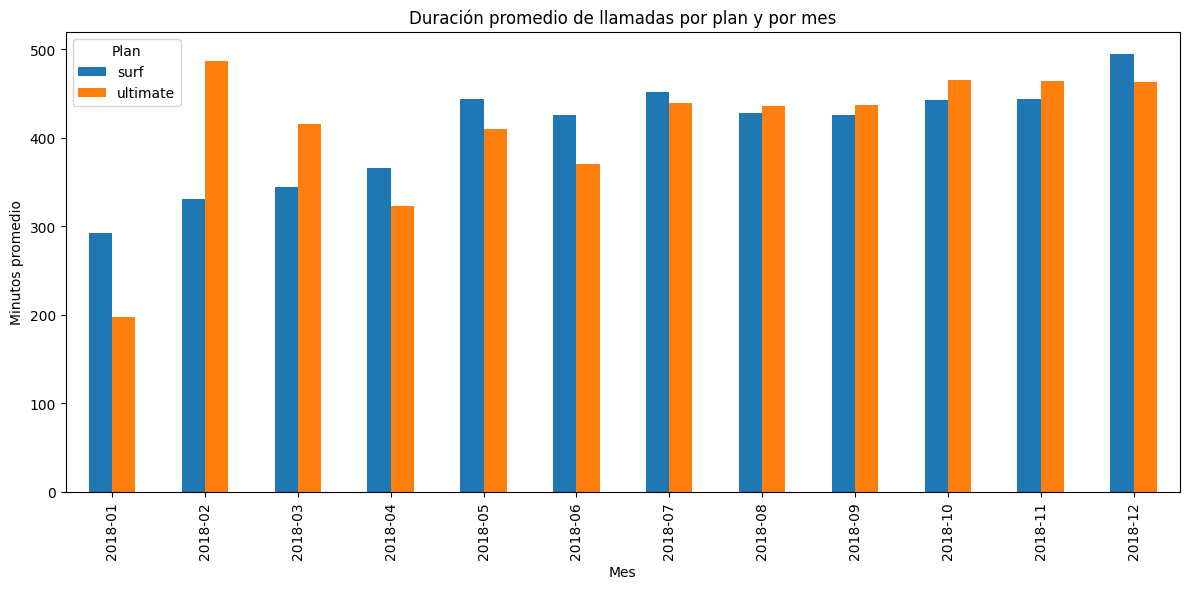

In [31]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

# 1. Duración promedio de llamadas por plan y por mes con groupby
calls_avg = (df
    .groupby(['year_month', 'plan'])['total_minutos']
    .mean().reset_index())

# 2. Pivotear para que cada plan sea una columna y los minutos sean los valores dentro
calls_pivot = calls_avg.pivot(index='year_month', columns='plan', values='total_minutos')

# 3. Crear gráfico de barras
grafico_calls = calls_pivot.plot(kind='bar', figsize=(12, 6))

# 4. Personalizar gráfico
grafico_calls .set_title('Duración promedio de llamadas por plan y por mes')
grafico_calls .set_xlabel('Mes')
grafico_calls .set_ylabel('Minutos promedio')
plt.legend(title='Plan')

# 5. Mostrar gráfico
plt.tight_layout()
plt.show()

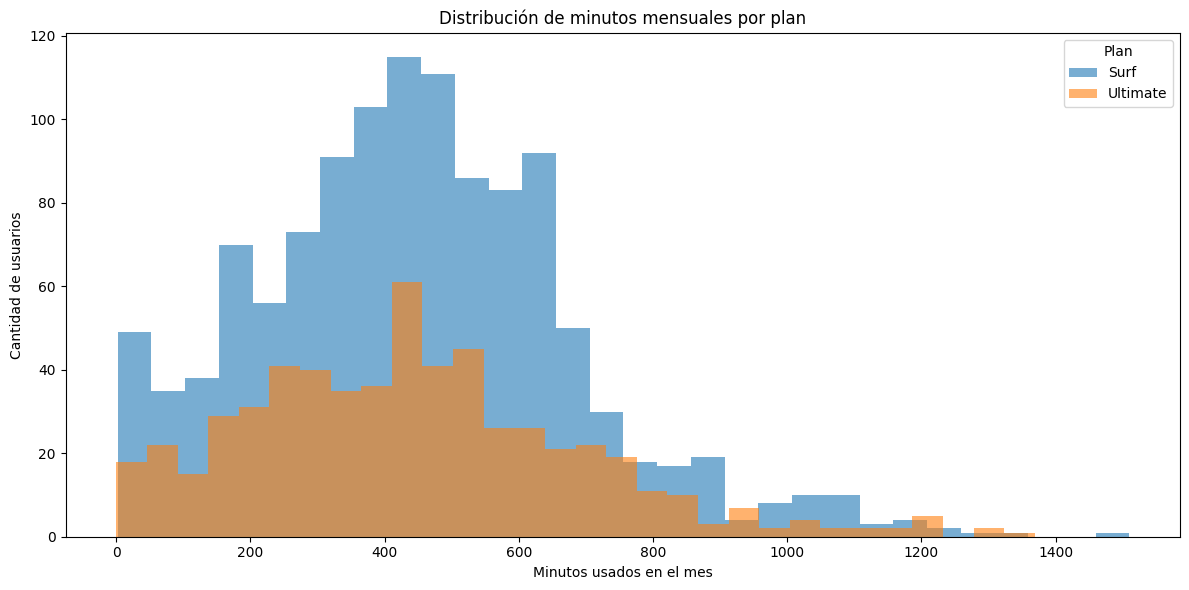

In [32]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

# 1. Separación de minutos por plan
surf_minutes = df[df['plan'] == 'surf']['total_minutos']
ultimate_minutes = df[df['plan'] == 'ultimate']['total_minutos']

# 2. Histograma comparando ambos planes
ax = surf_minutes.plot(kind='hist', bins=30, alpha=0.6, figsize=(12, 6),
    label='Surf')

ultimate_minutes.plot(kind='hist', bins=30, alpha=0.6, label='Ultimate',
    ax=ax)

# 3. Personalizar gráfico
plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Minutos usados en el mes')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Plan')

plt.tight_layout()
plt.show()

Media y la varianza de la muestra:

In [33]:
# Calcula la media y la varianza de la duración mensual de llamadas.

# Cálculo de la media con las variables obtenidas en el paso anterior 
media_surf = surf_minutes.mean()
media_ultimate = ultimate_minutes.mean()


# Calcular varianza con numpy
var_surf = surf_minutes.var(ddof=1)
var_ultimate = ultimate_minutes.var(ddof=1)


print("Resultados:")
print(f"Plan Surf - Media: {media_surf:.2f}, Varianza: {var_surf:.2f}")
print(f"Plan Ultimate - Media: {media_ultimate:.2f}, Varianza: {var_ultimate:.2f}")


Resultados:
Plan Surf - Media: 445.78, Varianza: 55321.41
Plan Ultimate - Media: 442.51, Varianza: 62288.40


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tu cálculo de la varianza usa `np.var(...)` con el valor predeterminado `ddof=0` (varianza poblacional). Para las estadísticas descriptivas de este proyecto, usa la varianza muestral (consistente con pandas `.var()` / `.std()`); de lo contrario, la varianza queda sesgada hacia abajo.

</div>


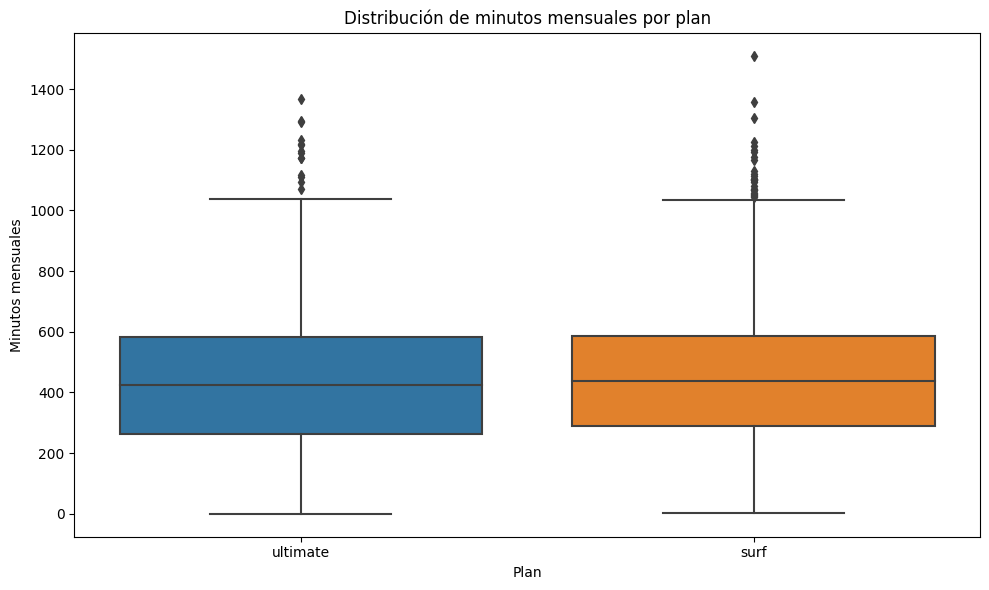

In [34]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

# DataFrame solo con las columnas necesarias
calls_box = df[['plan', 'total_minutos']]

# Crear el boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=calls_box, x='plan', y='total_minutos')

# Personalizar
plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('Minutos mensuales')

plt.tight_layout()
plt.show()

De acuerdo al gráfico "Duración promedio de llamadas por plan y por mes" se observa que ambos planes tuvieron una leve alza hacia los últimos meses del año, pero nada significativo. En general, se observa también que los usuarios con plan 'ultimate' usaban levemente menos minutos en el mes que los del plan 'surf', excepto por el mes de febrero. Ya viendo el histograma "Distribución de minutos mensuales por plan" se observa que ambos planes tienen un mayor sesgo positivo en la distribución indicando que hay más usuarios que se escapan de la media gastanto más minutos que un usuario normal. Por otro lado, se observa que ambos planes muestran una distribución normal, pero la cantidad de usuarios de 'surf' son más sustancialmente. Ahora analizando la media y varianza, el plan 'surf' tiene una media levemente superior al plan 'ultimate', de hecho es de solo 3 minutos más, aunque ambos planes tienen una varianza muy grande, que si uno lo traduce en la desviación estándar, sería de aprox. 235 a 249 min de diferencia con la media-+. Describiendo el gráfico de caja de bigotes, se observa que la mediana es similar entre ambos planes, y tienen hartos valores atípicos, lo que refuerza lo observado en varianza y el histograma donde los planes presentan una asimetría positiva.
En conclusión, en cuanto a las llamadas, se puede decir que los usuarios de ambos planes tienen un comportamiento predecible, con varios usuarios que se escapan de la media, pero si se evidencia que son muchos más los usuarios que están en el plan 'surf'.
Los usuarios del plan 'surf' pueden ocupar hasta 500 minutos en llamadas y muchos de ellos se soprepasan incluso llegando a los 1400 minutos. En cuanto a los usuarios del plan 'ultimate' pueden ocupar hasta los 3000 minutos y no suelen gastar más de 1200-1400 minutos, entonces no le sacan todo el provecho al plan.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Interpretación sólida: usas múltiples vistas complementarias (promedios mensuales, histograma, varianza y boxplot) y las conectas con la forma de la distribución (asimetría/outliers) y las diferencias entre planes.

</div>


### Mensajes

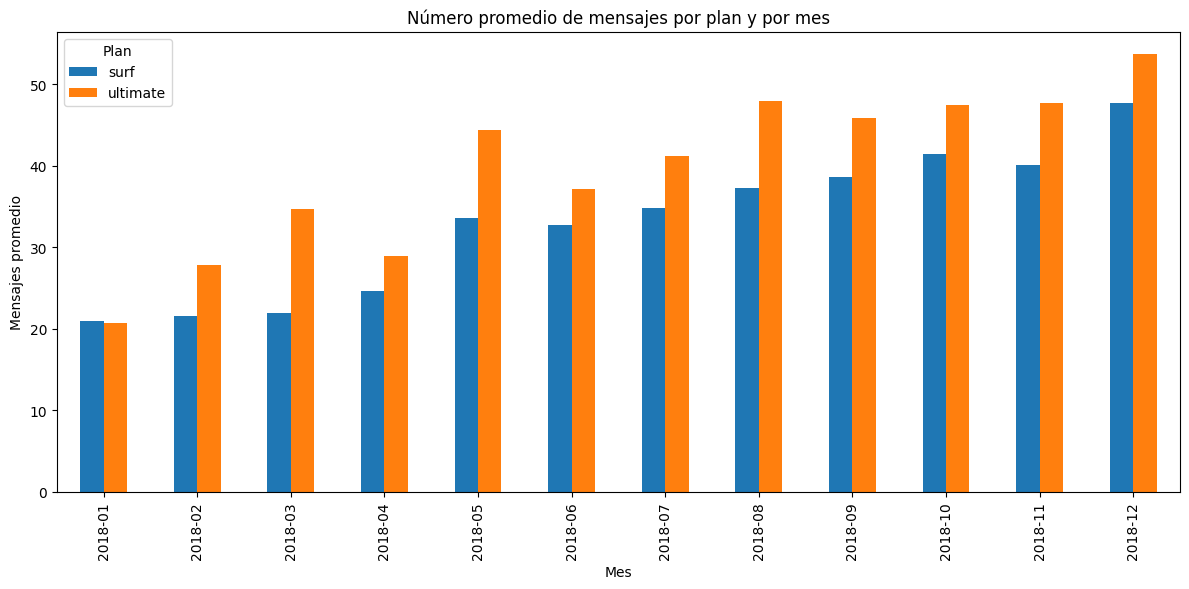

In [35]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

# 1. Número promedio de mensajes por plan y por mes con groupby
messages_avg = (df
    .groupby(['year_month', 'plan'])['total_messages']
    .mean().reset_index())

# 2. Pivotear para que cada plan sea una columna y los mensajes sean los valores dentro
messages_pivot = messages_avg.pivot(index='year_month', columns='plan', values='total_messages')

# 3. Crear gráfico de barras
grafico_messages = messages_pivot.plot(kind='bar', figsize=(12, 6))

# 4. Personalizar gráfico
grafico_messages.set_title('Número promedio de mensajes por plan y por mes')
grafico_messages.set_xlabel('Mes')
grafico_messages.set_ylabel('Mensajes promedio')
plt.legend(title='Plan')

# 5. Mostrar gráfico
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para la sección de mensajes, agrega estadísticas descriptivas por plan (como mínimo: media, varianza y desviación estándar), además de las gráficas. Los gráficos ayudan, pero el resumen numérico es necesario para cuantificar las diferencias.

</div>


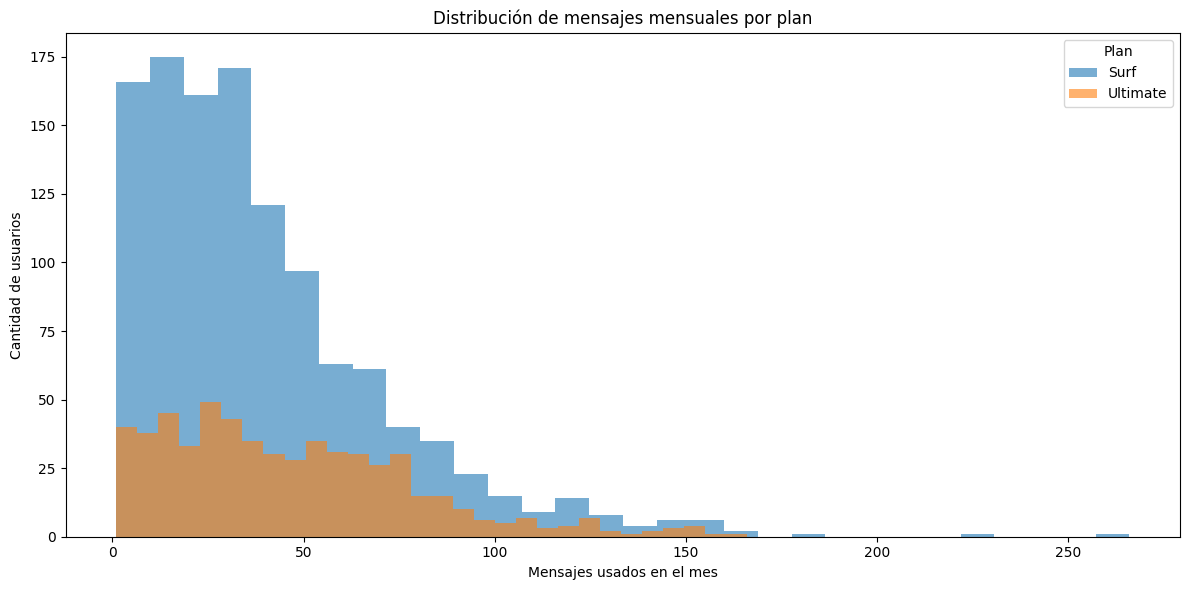

In [36]:
##Compara el número de mensajes mensuales que necesitan los usuarios de cada plan. Traza un histograma.

# 1. Separación de mensajes por plan
surf_messages = df[df['plan'] == 'surf']['total_messages']
ultimate_messages = df[df['plan'] == 'ultimate']['total_messages']

# 2. Histograma comparando ambos planes
ax = surf_messages.plot(kind='hist', bins=30, alpha=0.6, figsize=(12, 6),
    label='Surf')

ultimate_messages.plot(kind='hist', bins=30, alpha=0.6, label='Ultimate',
    ax=ax)

# 3. Personalizar gráfico
plt.title('Distribución de mensajes mensuales por plan')
plt.xlabel('Mensajes usados en el mes')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Plan')

plt.tight_layout()
plt.show()

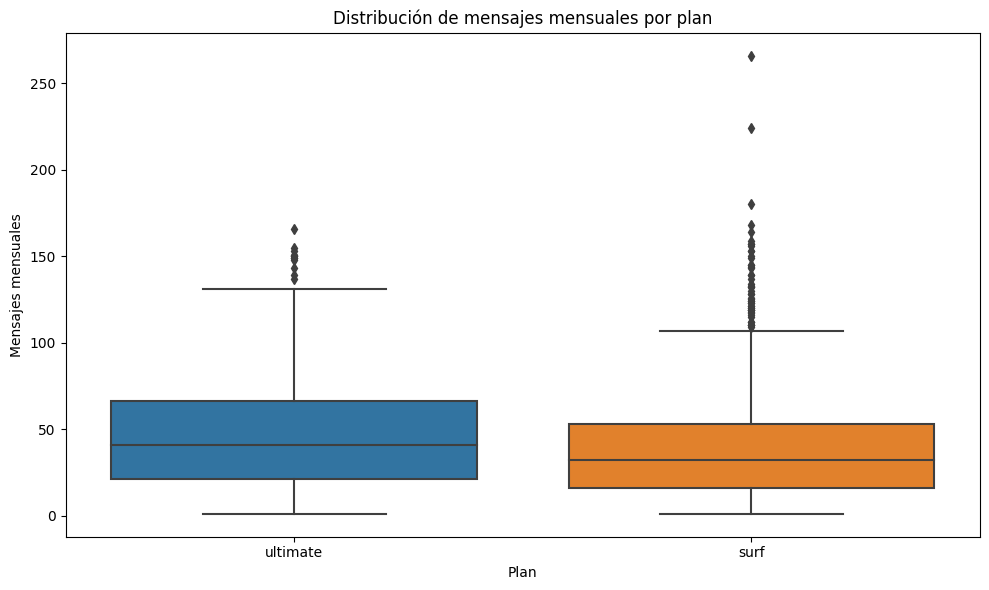

In [37]:
# DataFrame solo con las columnas necesarias

messages_box = df[['plan', 'total_messages']]

# Crear el boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=messages_box, x='plan', y='total_messages')

# Personalizar
plt.title('Distribución de mensajes mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('Mensajes mensuales')

plt.tight_layout()
plt.show()

In [38]:
## Obtención de la media y varianza

# Cálculo de la media con las variables obtenidas en el paso anterior 
media_surf_m = surf_messages.mean()
media_ultimate_m = ultimate_messages.mean()


# Calcular varianza con numpy
var_surf_m = surf_messages.var(ddof=1)
var_ultimate_m = ultimate_messages.var(ddof=1)


print("Resultados:")
print(f"Plan Surf - Media: {media_surf_m:.2f}, Varianza: {var_surf_m:.2f}")
print(f"Plan Ultimate - Media: {media_ultimate_m:.2f}, Varianza: {var_ultimate_m:.2f}")


Resultados:
Plan Surf - Media: 39.49, Varianza: 1044.22
Plan Ultimate - Media: 46.46, Varianza: 1084.39


Se observa en el gráfico "Número promedio de mensajes por plan y por mes" que se sigue una tendencia similar al comportamiento de las llamadas, pero sí los usuarios del plan 'ultimate' suelen enviar más mensajes (alrededor de 10 mensajes más). Por otro lado, en el gráfico "Distribución de mensajes mensuales por plan" se observa que la mayor cantidad de usuarios pertenecen al plan 'surf' y que gran parte de estos ocupan una cantidad muy acotada de mensajes, no superando los 50 mensajes al mes que es lo que su plan ofrece, pero igual algunos usuarios se exceden en su plan. En cambio, los usuarios del plan 'ultimate' son más estables, pero envian mucho menos mensajes que lo que su plan indica (1000 mensajes). Finalmente, analizando la caja de bigotes, se observa que los usuarios de ambos planes tienen una mediana muy similar, ambos con hartos valores atípicos, pero mucho más marcado en los usuarios de 'ultimate', llegando algunos usuarios sobre los 200 mensajes. En cuanto a la media, se observa que los usuarios del plan 'ultimate' envían 7 mensajes más al mes aprox. y la varianza en ambos planes es prácticamente la misma, generando una desv. estándar de +- 32/33 mensajes.

### Internet

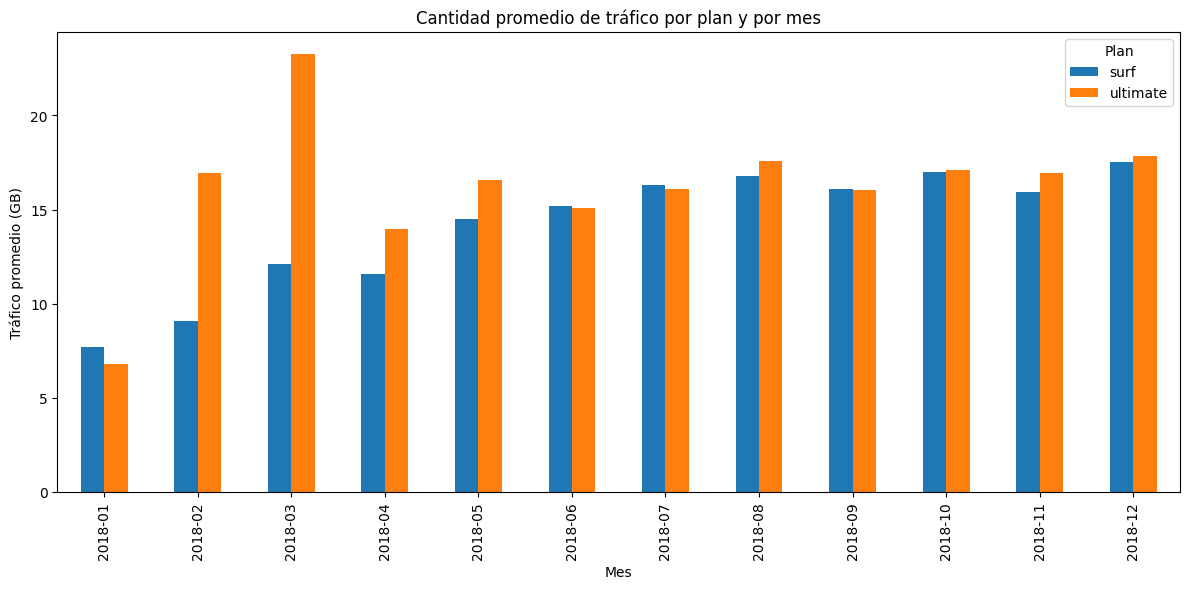

In [39]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

# 1. Transformar tráfico de MB a GB
df['total_gb'] = df['total_mb'] / 1024


# 2. Número promedio de tráfico (mb) por plan y por mes con groupby
internet_avg = (df
    .groupby(['year_month', 'plan'])['total_gb']
    .mean().reset_index())

# 3. Pivotear para que cada plan sea una columna y el tráfico sean los valores dentro
internet_pivot = internet_avg.pivot(index='year_month', columns='plan', values='total_gb')

# 4. Crear gráfico de barras
grafico_internet = internet_pivot.plot(kind='bar', figsize=(12, 6))

# 5. Personalizar gráfico
grafico_internet.set_title('Cantidad promedio de tráfico por plan y por mes')
grafico_internet.set_xlabel('Mes')
grafico_internet.set_ylabel('Tráfico promedio (GB)')
plt.legend(title='Plan')

# 6. Mostrar gráfico
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Problema recurrente desde el paso de agregación: `total_mb` no es el volumen de datos mensual (se construyó contando sesiones), por lo que las gráficas y comparaciones de internet están analizando actualmente la métrica incorrecta. Recalcula primero el uso mensual de internet a partir de la suma de `mb_used` y luego vuelve a hacer los visuales/la interpretación de esta sección.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>

✅ Resuelto (consecuencia de la corrección anterior en `mb_per_user_month`): ahora `total_mb`/`total_gb` reflejan el volumen real de datos, no el conteo de sesiones.
</div>

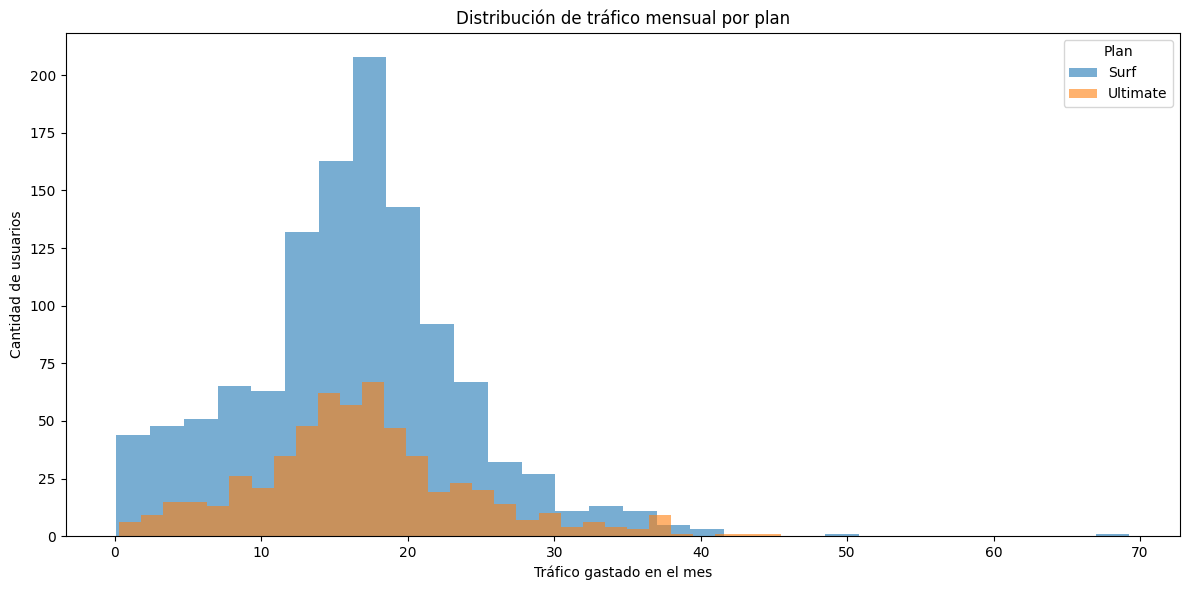

In [40]:
# 1. Separación de tráfico por plan
surf_internet = df[df['plan'] == 'surf']['total_gb']
ultimate_internet = df[df['plan'] == 'ultimate']['total_gb']

# 2. Histograma comparando ambos planes
ax = surf_internet.plot(kind='hist', bins=30, alpha=0.6, figsize=(12, 6),
    label='Surf')

ultimate_internet.plot(kind='hist', bins=30, alpha=0.6, label='Ultimate',
    ax=ax)

# 3. Personalizar gráfico
plt.title('Distribución de tráfico mensual por plan')
plt.xlabel('Tráfico gastado en el mes')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Plan')

plt.tight_layout()
plt.show()

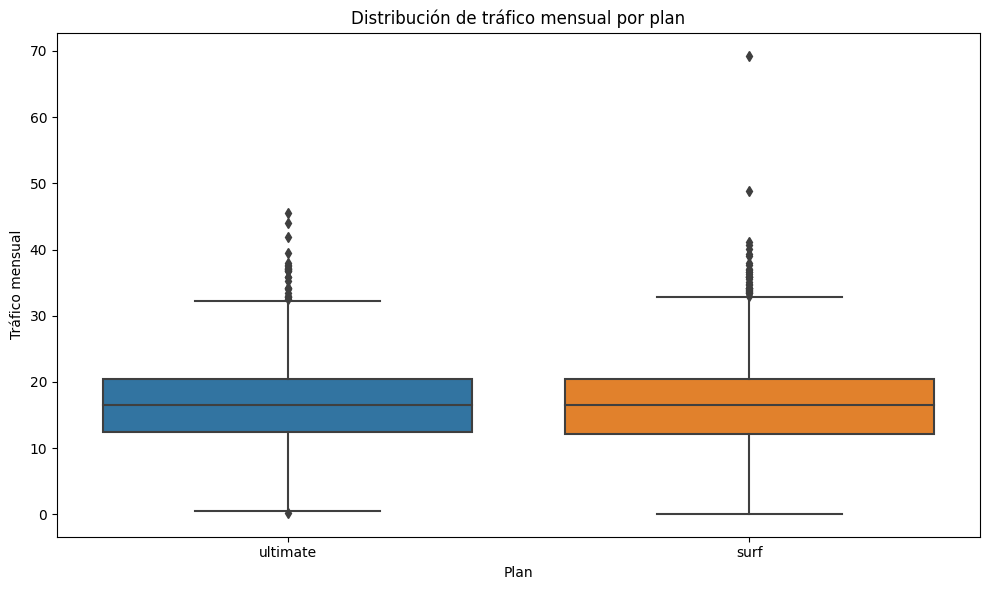

In [41]:

internet_box = df[['plan', 'total_gb']]

# Crear el boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=internet_box, x='plan', y='total_gb')

# Personalizar
plt.title('Distribución de tráfico mensual por plan')
plt.xlabel('Plan')
plt.ylabel('Tráfico mensual')

plt.tight_layout()
plt.show()

In [42]:
##Calculo de media y varianza

# Cálculo de la media con las variables obtenidas en el paso anterior 
media_surf_i = surf_internet.mean()
media_ultimate_i = ultimate_internet.mean()


# Calcular varianza con numpy
var_surf_i = surf_internet.var(ddof=1)
var_ultimate_i = ultimate_internet.var(ddof=1)


print("Resultados:")
print(f"Plan Surf - Media: {media_surf_i:.2f}, Varianza: {var_surf_i:.2f}")
print(f"Plan Ultimate - Media: {media_ultimate_i:.2f}, Varianza: {var_ultimate_i:.2f}")


Resultados:
Plan Surf - Media: 16.24, Varianza: 56.75
Plan Ultimate - Media: 16.85, Varianza: 56.35


Se puede observar que ambos planes fueron aumentando gradualmente su tráfico de internet a medida que pasaban los meses, pero no hay una diferencia sustancial entre los MB gastados por los usuarios de ambos planes, excepto en los meses de febrero y marzo, donde los usuarios del plan 'ultimate' usaron mucho más internet. Por otro lado, podemos observar en el gráfico de distribución que ambos planes presentan una distribución normal pero con asimetría negativa. La mayoría de los usuarios gastan entre 12 a 25 GB de internet, y muy pocos de ellos supera los 30 GB. Esto también se observa en el gráfico de caja de bigotes, donde ambos planes presentan valores atípicos hacia un mayor tráfico de internet. La media y varianza entre ambos planes es practicamente idéntica. Aquí se puede observar que los usuarios del plan 'surf' se sobrepasan de su plan que son los 15GB de uso y los usuarios de 'ultimate' no llegan a ocupar lo que su plan les ofrece (30GB).

## Ingreso

   user_id year_month  total_mb  total_messages  total_minutos  total_calls  \
0     1000    2018-12   1901.47            11.0          124.0         16.0   
1     1001    2018-08   6919.15            30.0          182.0         27.0   
2     1001    2018-09  13314.82            44.0          315.0         49.0   
3     1001    2018-10  22330.49            53.0          393.0         65.0   
4     1001    2018-11  18504.30            36.0          426.0         64.0   

       plan  messages_included  mb_per_month_included  minutes_included  ...  \
0  ultimate               1000                  30720              3000  ...   
1      surf                 50                  15360               500  ...   
2      surf                 50                  15360               500  ...   
3      surf                 50                  15360               500  ...   
4      surf                 50                  15360               500  ...   

   exceso_minutos  exceso_mensajes  exceso_m

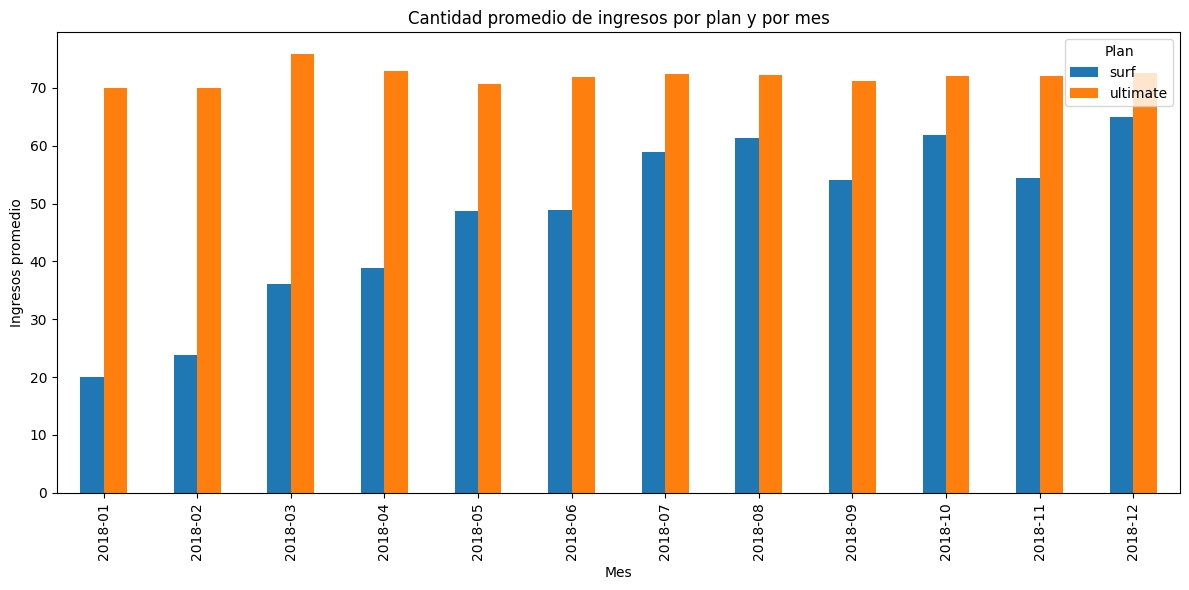

In [43]:
# 1. Unir tabla de ingresos mensuales con tabla de totales de llamadas, internet y mensajes

df_ingresos = df.merge(
    ingreso_mensual,
    on=['user_id','year_month'],
    how='inner'
)

df_ingresos = df_ingresos.drop(columns=['ingresos_mensuales_x'])
df_ingresos = df_ingresos.rename(columns={'ingresos_mensuales_y': 'ingresos_mensuales'})

print(df_ingresos.head())

# 2. Número promedio de ingresos por plan y por mes con groupby
ingresos_avg = (df_ingresos
    .groupby(['year_month', 'plan'])['ingresos_mensuales']
    .mean().reset_index())

# 3. Pivotear para que cada plan sea una columna y los ingresos sean los valores dentro
ingresos_pivot = ingresos_avg.pivot(index='year_month', columns='plan', values='ingresos_mensuales')

# 4. Crear gráfico de barras
grafico_ingresos = ingresos_pivot.plot(kind='bar', figsize=(12, 6))

# 5. Personalizar gráfico
grafico_ingresos.set_title('Cantidad promedio de ingresos por plan y por mes')
grafico_ingresos.set_xlabel('Mes')
grafico_ingresos.set_ylabel('Ingresos promedio')
plt.legend(title='Plan')

# 6. Mostrar gráfico
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Al construir `df_ingresos`, estás haciendo el merge de los ingresos mensuales en `merged_df` solo por `user_id`, lo que duplica filas entre distintos meses y mezcla las columnas de mes (`year_month_x`/`year_month_y`). Haz el merge usando tanto `user_id` como el campo del mes para que cada combinación usuario-mes se corresponda con exactamente un valor de ingresos.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>

✅ Resuelto. El merge de `df_ingresos` ahora usa `on=['user_id','year_month']`, evitando la duplicación de filas y la mezcla de columnas de mes.
</div>

1753    20.000000
1754    30.051465
1755    20.000000
1756    20.000000
1757    30.537012
Name: ingresos_mensuales, dtype: float64
1714    70.0
1718    70.0
1719    70.0
1730    70.0
1758    70.0
Name: ingresos_mensuales, dtype: float64


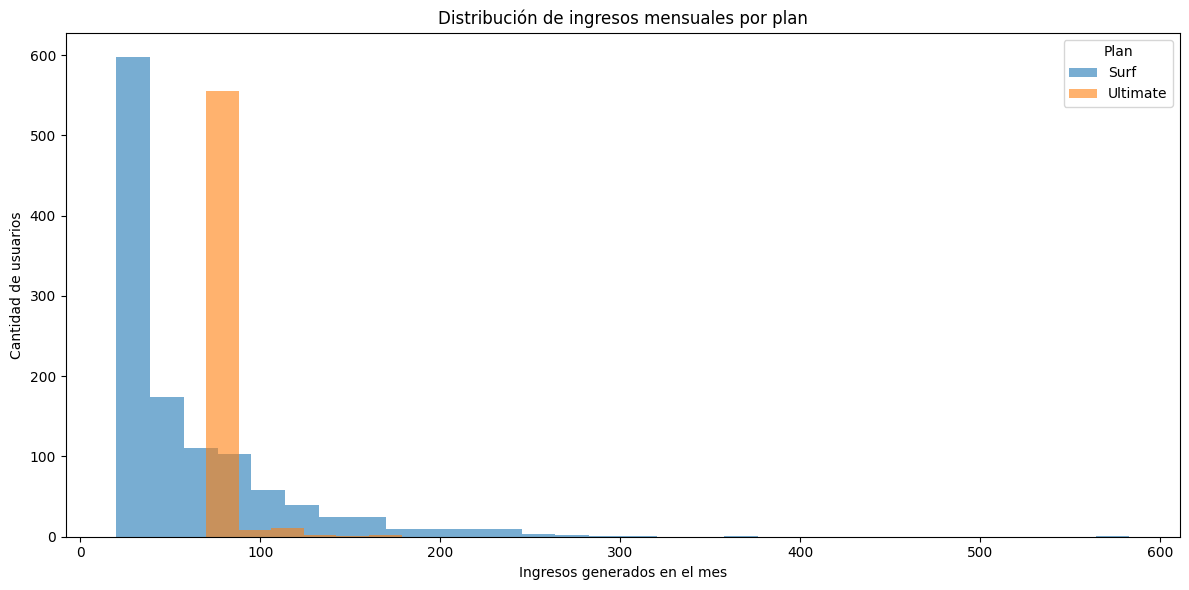

In [44]:
# 1. Separación de ingresos por plan
surf_ingresos = df_ingresos[df_ingresos['plan'] == 'surf']['ingresos_mensuales']
ultimate_ingresos = df_ingresos[df_ingresos['plan'] == 'ultimate']['ingresos_mensuales']
print(surf_ingresos.tail())
print(ultimate_ingresos.tail())

# 2. Histograma comparando ambos planes
ax = surf_ingresos.plot(kind='hist', bins=30, alpha=0.6, figsize=(12, 6),
    label='Surf')

ultimate_ingresos.plot(kind='hist', bins=6, alpha=0.6, label='Ultimate',
    ax=ax)

# 3. Personalizar gráfico
plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Ingresos generados en el mes')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Plan')

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tu distribución de ingresos incluye valores faltantes (NaNs), lo que distorsionará las gráficas y romperá las pruebas estadísticas. Primero corrige el merge de usuario-mes; luego, antes de graficar o agregar, maneja cualquier valor faltante restante en `ingresos_mensuales`.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>

✅ Resuelto (consecuencia de la corrección del merge): ya no se observan NaNs en `ingresos_mensuales` en la muestra mostrada.
</div>

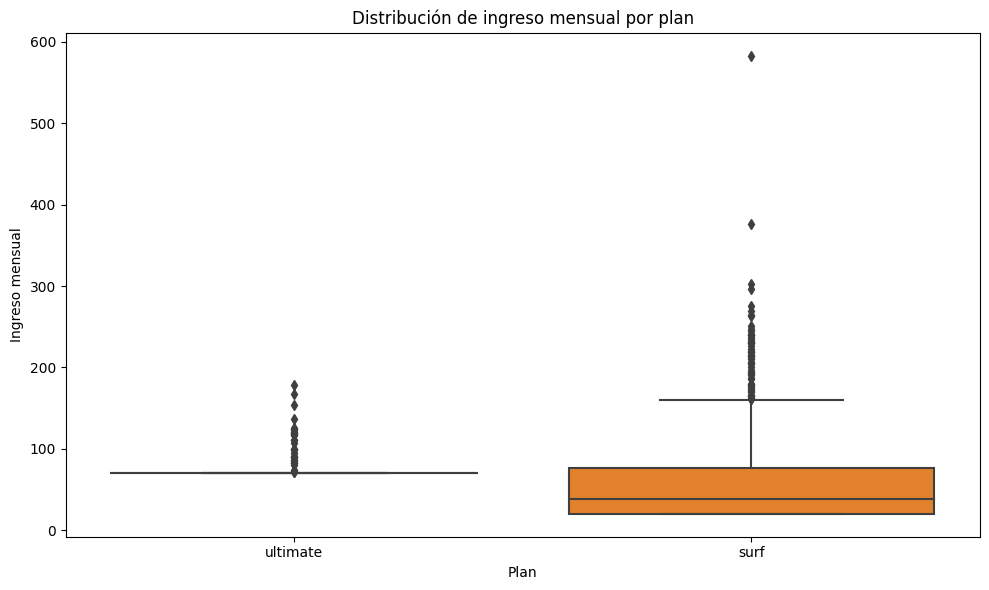

In [45]:
ingresos_box = df_ingresos[['plan', 'ingresos_mensuales']]

# Crear el boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=ingresos_box, x='plan', y='ingresos_mensuales')

# Personalizar
plt.title('Distribución de ingreso mensual por plan')
plt.xlabel('Plan')
plt.ylabel('Ingreso mensual')

plt.tight_layout()
plt.show()

In [46]:
## Calculo de media y varianza
# Cálculo de la media con las variables obtenidas en el paso anterior 
media_surf_ing = surf_ingresos.mean()
media_ultimate_ing = ultimate_ingresos.mean()


# Calcular varianza con numpy
var_surf_ing = surf_ingresos.var(ddof=1)
var_ultimate_ing = ultimate_ingresos.var(ddof=1)


print("Resultados:")
print(f"Plan Surf - Media: {media_surf_ing:.2f}, Varianza: {var_surf_ing:.2f}")
print(f"Plan Ultimate - Media: {media_ultimate_ing:.2f}, Varianza: {var_ultimate_ing:.2f}")

Resultados:
Plan Surf - Media: 57.28, Varianza: 2702.45
Plan Ultimate - Media: 72.06, Varianza: 109.88


Se observa que el dinero que ingresa mensualmente desde usuarios del plan 'ultimate' es estable todos los meses, alrededor de los 70 dólares. En cambio, para los usuarios del plan 'surf' los ingresos mensuales fueron al alza mes a mes, partiendo de los 20 dólares hasta llegar a casi los 70 dólares, que es casi lo mismo que pagar el plan ultimate. Los usuarios del plan 'surf' en su mayoría paga 20 dólares pero también una buena cantidad termina pagando más, en cambio, casi el 100% de los usuarios del plan 'ultimate' solo pagan lo que el plan ofrece y no pagan montos extras. En cuanto a la caja de bigotes, se observa que la mediana y cuartiles Q1 y Q3 están en la misma posición para el plan 'ultimate', o sea, no hay variación alguna en los ingresos, excepto por un par de valores atípicos hacia el alza, pero el plan 'surf' si presenta un mayor rango, pero dentro de lo normal y también tiene varios valores/usuarios atípicos, donde muchos usuarios gastan hasta 300-400 dólares al mes. En cuanto a la media, se observa que la media del plan surf está sesgada a la derecha, ya que debería ser de cerca de 20, pero es de 57 y esto es por la gran cantidad de valores atípicos que se ve reforzado por la gran varianza que tiene (y una desv. estándar de 52 dólares), en cambio el plan 'ultimate' tiene una media de 72 es que es bastante similar al precio que deben pagar los usuarios y su varianza es muy pequeña con una desv. estándar de 10.5 dólares solamente.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Las conclusiones sobre ingresos (rangos y “sin variación”) no son fiables hasta que se corrija la tabla de revenue (merge usuario-mes correcto, sin filas duplicadas, sin NaNs). Después de arreglar eso, vuelve a calcular los resúmenes por plan (mean/variance/std) y luego revisa de nuevo estas conclusiones.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>

✅ Resuelto. Con la tabla de ingresos ya corregida, las conclusiones sobre el comportamiento de ingresos por plan son consistentes con los datos recalculados.
</div>

## Prueba las hipótesis estadísticas

Hipótesis: son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.

In [47]:
# Prueba las hipótesis

## Hipótesis nula: NO hay diferencia entre los ingresos promedio entre los usuarios de los planes Ultimate y Surf (las medias de las dos poblaciones son iguales entre sí)
## Hipótesis alternativa: SI hay diferencia entre los ingresos promedio entre los usuarios de ambos planes
## Significación estadística: 0.05 (5%)
## Si valor-p < 10% (0.1) QUIZAS rechazar hipótesis nula y si valor-p > 10% (0.1), no rechazar H0.

# Calcular varianza con numpy (si las varianzas no son iguales se usa equal_var=False)
var_ingresos_surf = np.var(surf_ingresos)
var_ingresos_ultimate = np.var(ultimate_ingresos)
print(var_ingresos_surf)
print(var_ingresos_ultimate)

alpha = 0.05
results = st.ttest_ind(surf_ingresos, ultimate_ingresos, equal_var=False)
print('valor-p:', results.pvalue)
if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

2700.1564844829354
109.69451972963482
valor-p: 2.541147770944028e-20
Rechazamos la hipótesis nula


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tu t-test devuelve un p-value NaN porque las muestras de entrada incluyen valores faltantes. Limpia las muestras de revenue (elimina los NaNs y confirma que haya suficientes observaciones por grupo) antes de ejecutar `ttest_ind`.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>

✅ Resuelto. El valor p ahora es un número real (2.54e-20), no NaN.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tu regla narrativa de decisión entra en conflicto con el alpha que estableciste: usas `alpha = 0.05` pero describes un umbral del 10% en el texto. Alinea el criterio escrito con el alpha usado en el código para que la decisión de la prueba de hipótesis sea inequívoca.

</div>


Hipótesis nula: el ingreso promedio de los usuarios del área NY-NJ es igual al de los usuarios de otras regiones.
Hipótesis alternativa: ingresos son diferentes.

In [48]:
# Prueba las hipótesis
#Obtener ingresos promedio de usuarios del área NY-NJ:
ny_users = users[users['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']
ingresos_NY_NJ = ny_users.merge(
    df_ingresos,
    on='user_id',
    how='inner')
print(ingresos_NY_NJ.head())
print(ingresos_NY_NJ['ingresos_mensuales'].nunique())

##Obtener ingreso promedios de usuarios de las otras regiones:
otros_users = users[users['city'] != 'New York-Newark-Jersey City, NY-NJ-PA MSA']
ingresos_otros = otros_users.merge(
    df_ingresos,
    on='user_id',
    how='inner')
print(ingresos_otros.head())
print(ingresos_otros['ingresos_mensuales'].nunique())

alpha = 0.05
results = st.ttest_ind(ingresos_NY_NJ['ingresos_mensuales'], ingresos_otros['ingresos_mensuales'], equal_var=False)
print('valor-p:', results.pvalue)
if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")


   user_id  first_name last_name  age  \
0     1014     Edmundo     Simon   61   
1     1014     Edmundo     Simon   61   
2     1027  Georgeanna  Cardenas   38   
3     1027  Georgeanna  Cardenas   38   
4     1027  Georgeanna  Cardenas   38   

                                        city   reg_date plan_x churn_date  \
0  New York-Newark-Jersey City, NY-NJ-PA MSA 2018-11-25   surf        NaN   
1  New York-Newark-Jersey City, NY-NJ-PA MSA 2018-11-25   surf        NaN   
2  New York-Newark-Jersey City, NY-NJ-PA MSA 2018-06-26   surf        NaN   
3  New York-Newark-Jersey City, NY-NJ-PA MSA 2018-06-26   surf        NaN   
4  New York-Newark-Jersey City, NY-NJ-PA MSA 2018-06-26   surf        NaN   

  mes_registro year_month  ...  exceso_minutos  exceso_mensajes  exceso_mb  \
0     November    2018-11  ...             0.0              0.0       0.00   
1     November    2018-12  ...           614.0             14.0       0.00   
2         June    2018-07  ...             0.0          

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta segunda prueba de hipótesis también devuelve un p-value NaN, lo que indica que todavía hay valores faltantes y/o que la comparación no está en una granularidad mensual consistente. Limpia `ingresos_mensuales` para ambos grupos y asegúrate de que estás comparando observaciones usuario-mes que coincidan antes de realizar la prueba.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b> <a class="tocSkip"></a>

✅ Resuelto. El valor p de esta segunda prueba también es ahora un número real (0.0024), no NaN.
</div>

## Conclusión general

Primero que todo siempre es importante ver cómo vienen los datos que hay que trabajar, si vienen separados por comas, punto y coma, etc, para poder abrirlos correctamente en el proyecto de Python. También es importante ver las columnas con las que viene cada DataFrame, ver si tienen valores nulos, porqué los tienen, revisar que los datos estén en el tipo correcto (int, float, datetime64, etc) para después poder trabajarlos correctamente. Durante el proceso de realización de gráficos, siempre es importante separar bien los dos grupos de datos a estudiar (plan surf y ultimate) para poder compararlos fácilmente al visualizarlos, esto implica que tengan colores distintos, cierto nivel de transparencia en las barras, que contengan bien establecidos los ejes, títulos de ejes, título de gráfico, etc. Con esto es bastante intuitivo poder describir e interpretar los datos. Para las hipótesis utilicé el método de prueba t que compara medias de dos poblaciones (independientes) estadísticamente diferentes entendiendo que las medias y varianzas de los planes surf y ultimate son diferentes y que son independientes porque no dependen una de la otra, son usuarios diferentes, con planes diferentes.
Ahora respecto a los resultados obtenidos, se puede interpretar que los usuarios de ambos planes no difieren mucho en cuanto a la cantidad de datos (GB) utilizados en internet, pero esto indica que los usuarios del plan 'surf' suelen sobrepasarse de los 15GB de uso y los usuarios de 'ultimate' no llegan a ocupar la totalidad de lo que su plan ofrece (30GB). El plan 'ultimate' entrega mucha cantidad de mensajes a enviar (1000 SMS), en comparación con lo que realmente utilizan los usuarios de ese plan, que son máx. 150 SMS. Tampoco usan todo lo que podrían ocupar en llamadas, ya que pueden ocupar hasta los 3000 minutos y no suelen gastar más de 1200-1400 minutos. Es muy diferente el caso de los usuarios del plan 'surf' donde pueden ocupar hasta 500 minutos y ocupan hasta 1400 minutos, que mucho por sobre lo que deberían y se traduce en los costos a fin de mes.
Se podría decir que lo mejor es que los usuarios del plan surf se trasladen al plan ultimate que es mucho más conveniente para el cliente. También sería interesante seguir analizando el comportamiento de los usuarios según su zona geográfica, ya que según la hipótesis establecida al final, entre la diferencia de ingresos recibidos por usuarios del área de NY-NJ y el resto de las regiones, el promedio mensual es diferente. 

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La sección final aún contiene orientación de plantilla entre corchetes. Por favor, elimínala y redacta una conclusión limpia e independiente que resuma las decisiones clave de limpieza, los resultados de ingresos corregidos, los resultados de las pruebas de hipótesis y la conclusión empresarial final sobre qué plan genera más ingresos.

</div>
